In [1]:
# Load the sales superstore dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Sales_Superstore_Data.csv', encoding='latin-1')
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Calculate and display the key performance indicators (KPIs)

In [3]:
# Calculate total revenue
total_revenue = df['Sales'].sum()
print(f'Total Revenue: ${total_revenue:.2f}')

Total Revenue: $2297200.86


In [4]:
# Calculate average order value
avg_order_value = df['Sales'].sum() / df['Order ID'].nunique()
print(f'Average Order Value: ${avg_order_value:.2f}')

Average Order Value: $458.61


In [5]:
# Identify top regions by sales
top_regions = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(5)
print('Top Regions by Sales:')
print(top_regions)

Top Regions by Sales:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


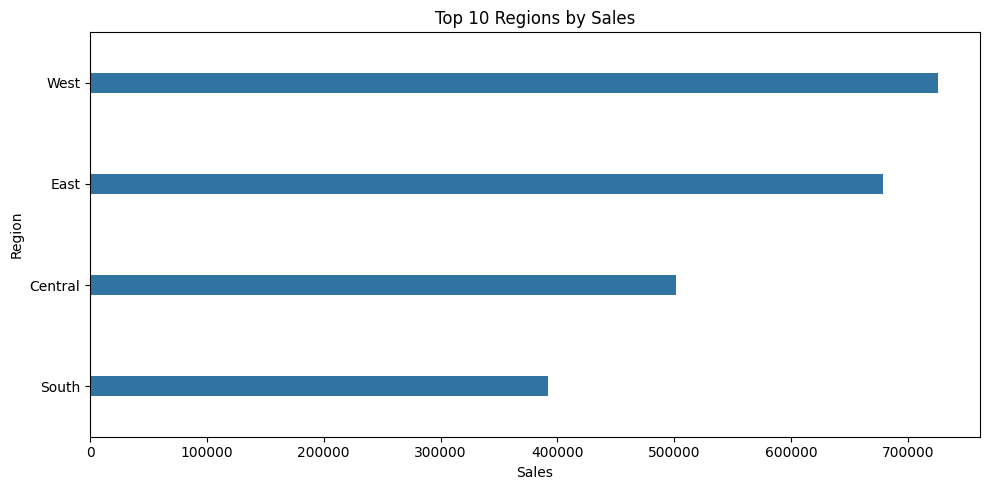

In [6]:
# Display the top regions in a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=top_regions.values, y=top_regions.index,width=0.2)
plt.title('Top 10 Regions by Sales')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('top_regions.png')
plt.show()

In [14]:
# Calculate and display trends and sales over time
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
sales_over_time = df.set_index('Order Date')['Sales'].resample('M').sum()
print('Sales Over Time:')
print(sales_over_time)


Sales Over Time:
Order Date
2014-01-31     14236.8950
2014-02-28      4519.8920
2014-03-31     55691.0090
2014-04-30     28295.3450
2014-05-31     23648.2870
2014-06-30     34595.1276
2014-07-31     33946.3930
2014-08-31     27909.4685
2014-09-30     81777.3508
2014-10-31     31453.3930
2014-11-30     78628.7167
2014-12-31     69545.6205
2015-01-31     18174.0756
2015-02-28     11951.4110
2015-03-31     38726.2520
2015-04-30     34195.2085
2015-05-31     30131.6865
2015-06-30     24797.2920
2015-07-31     28765.3250
2015-08-31     36898.3322
2015-09-30     64595.9180
2015-10-31     31404.9235
2015-11-30     75972.5635
2015-12-31     74919.5212
2016-01-31     18542.4910
2016-02-29     22978.8150
2016-03-31     51715.8750
2016-04-30     38750.0390
2016-05-31     56987.7280
2016-06-30     40344.5340
2016-07-31     39261.9630
2016-08-31     31115.3743
2016-09-30     73410.0249
2016-10-31     59687.7450
2016-11-30     79411.9658
2016-12-31     96999.0430
2017-01-31     43971.3740
2017-02-28

C:\Users\nilad\AppData\Local\Temp\ipykernel_13736\914272248.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_over_time = df.set_index('Order Date')['Sales'].resample('M').sum()


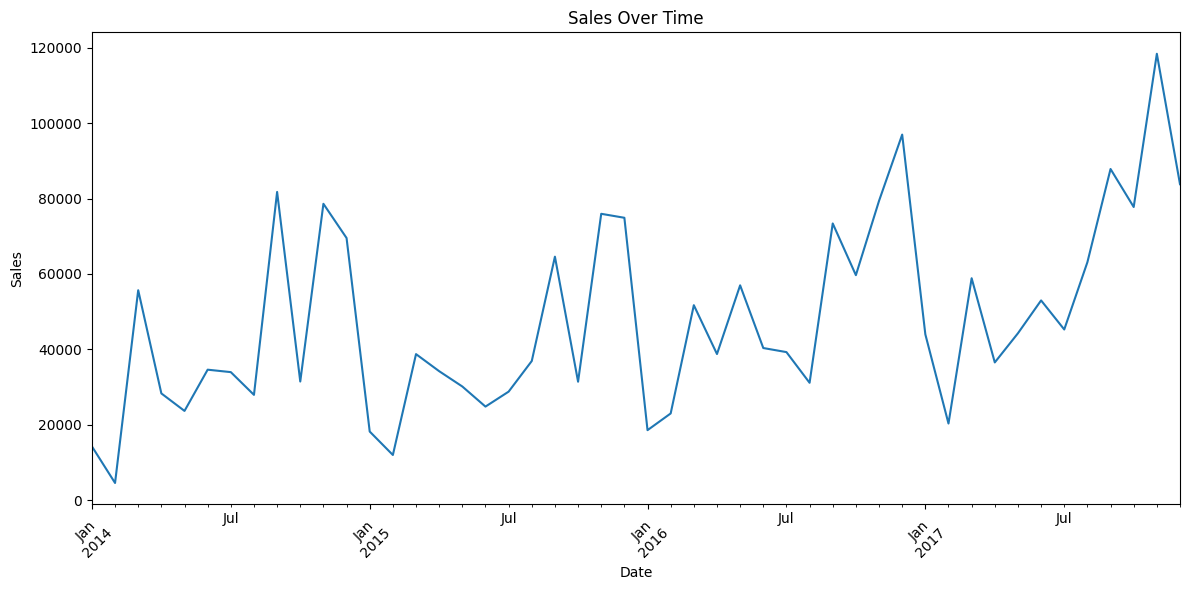

In [15]:
# Display the visual of the sales over time
plt.figure(figsize=(12, 6))
sales_over_time.plot()
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_over_time.png')
plt.show()


In [ ]:
# Calculate the top 10 products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print('Top 10 Products by Sales:')
print(top_products)

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


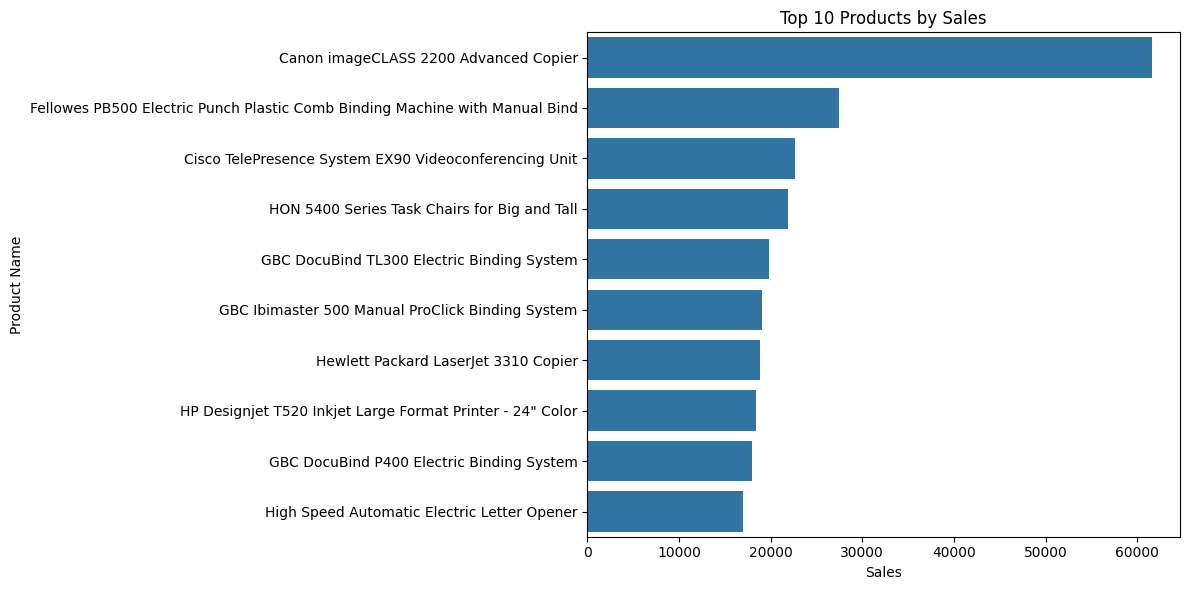

In [ ]:
# Visualize the top products
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()


In [ ]:
# Identify the most frequent and profitable customers
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print('Top Customers by Sales:')
print(top_customers)

Top Customers by Sales:
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


<Figure size 1200x600 with 0 Axes>

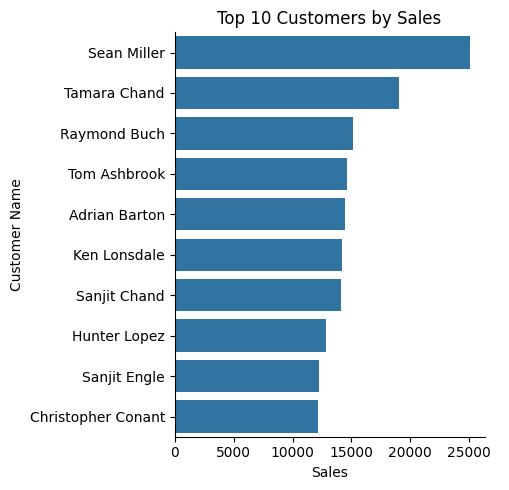

In [ ]:
# Visualize the top customers
plt.figure(figsize=(12, 6))
sns.catplot(x=top_customers.values, y=top_customers.index, kind='bar')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.savefig('top_customers.png')
plt.show()

In [8]:
# calculate the profit of different categories
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print('Profit by Category:')
print(category_profit)

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [16]:
# Calculate the profit margin for each category
profit_margin_category = (df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum()) * 100
print('Profit Margin by Category (%):')
print(profit_margin_category.sort_values(ascending=False))

Profit Margin by Category (%):
Category
Technology         17.395712
Office Supplies    17.035158
Furniture           2.486695
dtype: float64


# Based on the top products, regions and customers present recommendations -
# like focusing marketing efforts on the top regions, offering promotions on the top products, and providing personalized offers to the top customers to increase sales and customer loyalty, and for the regions or products or customers having a less contribution towards the sales and revenue, we can analyze the reasons behind it and take necessary actions to improve their performance.
# The most profitable customers can be targeted with loyalty programs and exclusive offers to retain them and encourage repeat purchases. Additionally, analyzing the sales trends over time can help identify seasonal patterns and plan inventory and marketing strategies accordingly.
